In [ ]:
import matplotlib.pyplot as plt

from motion_planning.obstacle_sets import BiasedPassage
from motion_planning.search import MedialAxisPRM, MedialAxisRRT
from motion_planning.space import ApproximationSpace, PointRobot

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


# Setup Robot & Environment

In [2]:
env = PointRobot()
env.set_obstacles(BiasedPassage(bias=0.5, num_walls=3))

In [3]:
start, target = env.sample_task()

# Setup Approximation Space

In [4]:
env = ApproximationSpace(env, batch_size=1000, do_overapproximation=True)

/Users/pravaltelagi/motion_planning/motion_planning/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


# MedialAxisRRT

In [5]:
rrt = MedialAxisRRT(env)
path = rrt.search(start=start, target=target, max_steps=10000, goal_bias=0.1)

Num MedialAxis Points: 209
Search Time: 5.265243053436279, Collision Checks: 7163


/Users/pravaltelagi/motion_planning/motion_planning/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


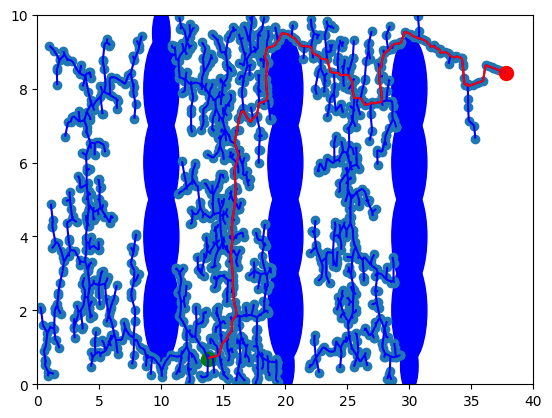

In [6]:
rrt.draw_tree(plt.gca(), path=path)

# MedialAxisPRM

In [7]:
prm = MedialAxisPRM(env, num_samples=750, num_neighbors=5)
prm.create_graph()

Num MedialAxis Points: 210
Connecting Edges Using knn strategy


/Users/pravaltelagi/motion_planning/motion_planning/utils.py:105: RuntimeWarning: invalid value encountered in divide
  normalized_gradients = gradients / lengths.reshape(-1, 1) # TODO: Probably need to reshape # (B, d)


In [8]:
path = prm.search(start=start, target=target)

/Users/pravaltelagi/motion_planning/motion_planning/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


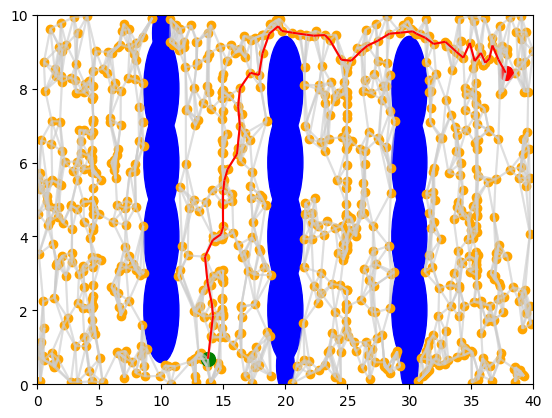

In [11]:
env.draw_environment(plt.gca())
prm.draw(plt.gca(), path=path, show_task=True)